In [1]:
from mw_plot import MWFaceOn, MWSkyMap
from mw_plot.base import MWPlotCommon
import astropy.units as u
import astropy.coordinates as coord
import numpy as np

### Plotting on Gaia Face-On Milky Way Image

In [2]:

mw = MWFaceOn(map='gaia', radius=20*u.kpc, unit=u.kpc, coord='galactocentric')

img = mw._MW_IMAGES["MW_gaia_faceon"]

print("Gaia Face-On MW Image Information")
print(f"Citation/Credit:    {img.citation}")
print(f"Source URL:  {img.source_url}")
print(f"License:     {img.license}")
print(f"Size:        {img.img_size_px[0]} × {img.img_size_px[1]} px")
print(f"Scale:       {img.kpc_per_pixel*1000:.2f} pc/px")
print(f"Coverage:    {img.img_size_px[0] * img.kpc_per_pixel:.0f} × {img.img_size_px[1] * img.kpc_per_pixel:.0f} kpc")

Gaia Face-On MW Image Information
Citation/Credit:    ESA/Gaia/DPAC, Stefan Payne-Wardenaar
Source URL:  https://www.esa.int/ESA_Multimedia/Images/2025/01/The_best_Milky_Way_map_by_Gaia
License:     CC BY-SA 3.0 IGO
Size:        5000 × 5000 px
Scale:       8.00 pc/px
Coverage:    40 × 40 kpc


Credit: ESA/Gaia/DPAC, Stefan Payne-Wardenaar | CC BY-SA 3.0 IGO


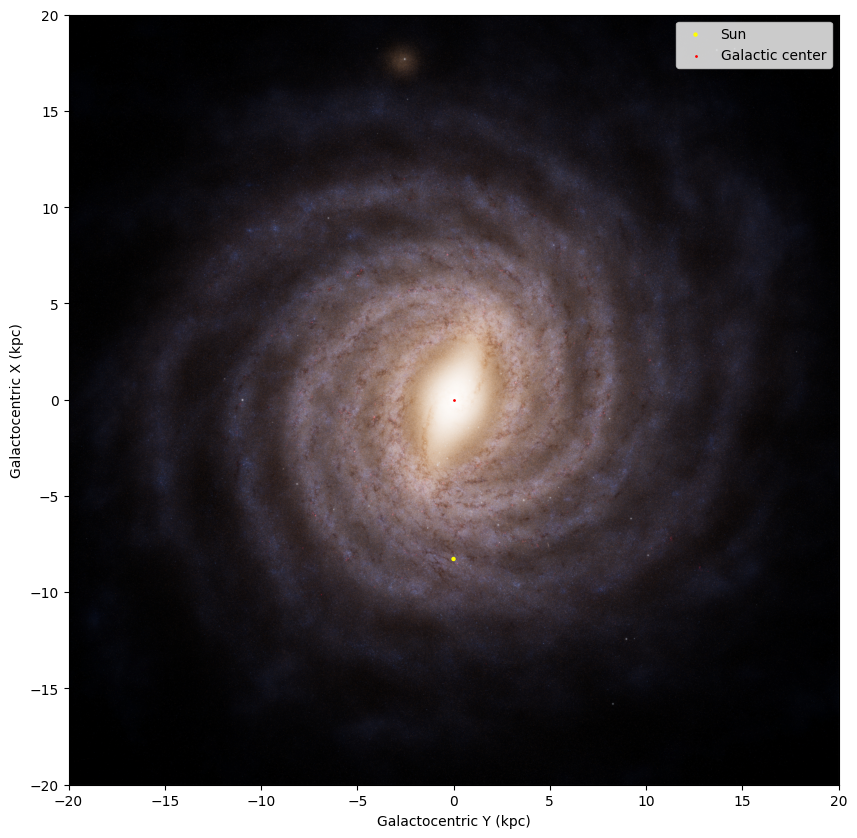

In [3]:
# Sun position options
# 'right': Sun to the right of GC, consistent with astropy/galpy convention, X axis horizontal, Y axis vertical
# 'bottom':Sun below GC, rotated 90° from standard convention swap axis labels to Galactocentric Y (x-axis) and X (y-axis)

sun_position = 'bottom'

mw = MWFaceOn(
    map='gaia',
    radius=20 * u.kpc,
    unit=u.kpc,
    coord='galactocentric',
    figsize=(10, 10),
    show_sun=True,
    sun_position=sun_position,
)
mw.scatter(0 * u.kpc, 0 * u.kpc, c='red', s=1, marker='o', label='Galactic center')
# citation, credit
#mw.ax.text(0.01, 0.01,f"© {img.citation} | {img.license}", transform=mw.ax.transAxes,fontsize=6,color='white',alpha=1,va='bottom')

if sun_position == 'right':
    mw.ax.set_xlabel('Galactocentric X (kpc)')
    mw.ax.set_ylabel('Galactocentric Y (kpc)')
else:
    mw.ax.set_xlabel('Galactocentric Y (kpc)')
    mw.ax.set_ylabel('Galactocentric X (kpc)')

print(f"Credit: {img.citation} | {img.license}")

# save with different resolutions
# max meaningful dpi = image_pixels / figsize_inches = 5000 / 10 = 500
# mw.savefig('mw_faceon_lowres.png',  dpi=72)   
# mw.savefig('mw_faceon_highres.png', dpi=500)  

Credit: ESA/Gaia/DPAC, Stefan Payne-Wardenaar | CC BY-SA 3.0 IGO


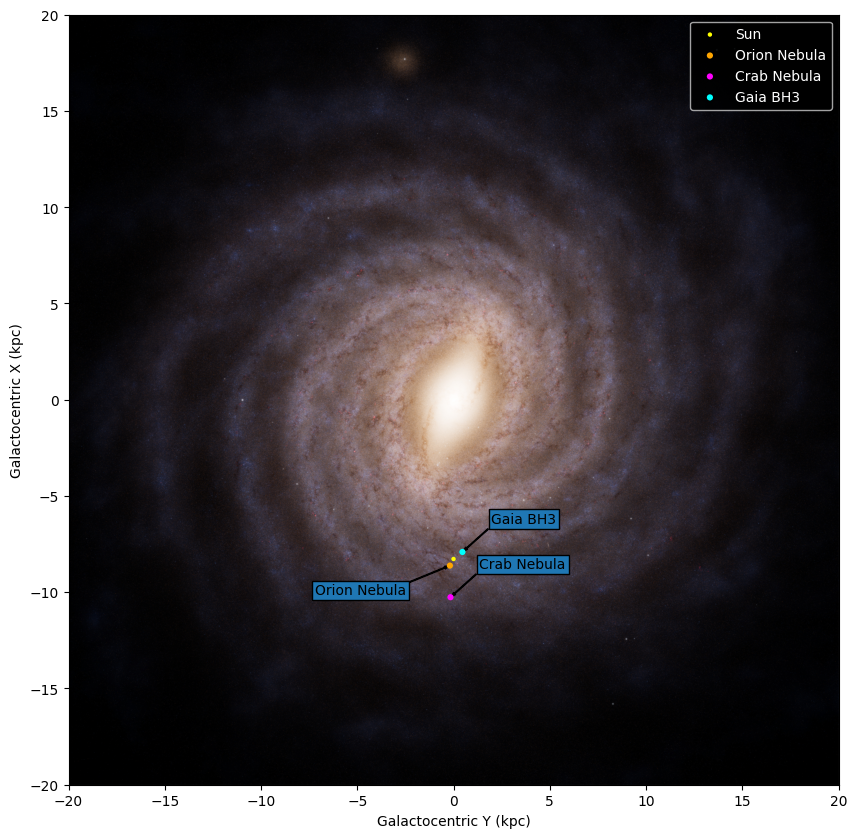

In [4]:
sun_position = 'bottom'

# example how to convert RA/Dec (degrees) to galactic l, b
# sky = coord.SkyCoord(ra=294.828 * u.deg, dec=14.932 * u.deg, frame='icrs')
# print(f"l={sky.galactic.l.deg:.4f}°, b={sky.galactic.b.deg:.4f}°")

# distance in kpc
objects = [
    dict(name='Orion Nebula', l=209.011, b=-19.384, d=0.414,
         color='orange',  marker='o', size=20, text_offset=(-7, -1.5)),
    dict(name='Crab Nebula',  l=184.554, b=-5.783,  d=2.0,
         color='magenta', marker='o', size=20, text_offset=(1.5, 1.5)),
    dict(name='Gaia BH3',     l=51.673,  b=-3.488,  d=0.5917,
         color='cyan',    marker='o', size=20, text_offset=(1.5, 1.5)),
]


mw2 = MWFaceOn(
    map='gaia',
    radius=20 * u.kpc,
    unit=u.kpc,
    coord='galactocentric',
    figsize=(10, 10),
    show_sun=True,
    sun_position=sun_position,
)

for obj in objects:
    sky = coord.SkyCoord(
        l=obj['l'] * u.deg,
        b=obj['b'] * u.deg,
        distance=obj['d'] * u.kpc,
        frame='galactic'
    )
    gc = sky.transform_to(coord.Galactocentric(galcen_distance=8.275 * u.kpc)) # r0 from GRAVITY 2022

    # coordinate mapping depends on orientation
    if sun_position == 'right':
        x = -gc.x.to(u.kpc)
        y =  gc.y.to(u.kpc)
    else:  # bottom
        x =  gc.y.to(u.kpc)
        y =  gc.x.to(u.kpc)

    mw2.scatter(x, y, c=obj['color'], s=obj['size'], zorder=5, edgecolors='none', label=obj['name'])
    mw2.scatter_annotate(obj['name'], [x, y], text_offset=obj['text_offset'], arrowprops=dict(facecolor='black', width=0.5, headwidth=2.0, headlength=4.0),fontsize=10,)
    mw2.ax.legend(loc='upper right', facecolor='black', labelcolor='white', fontsize=10, markerscale=1)

if sun_position == 'right':
    mw2.ax.set_xlabel('Galactocentric X (kpc)')
    mw2.ax.set_ylabel('Galactocentric Y (kpc)')
else:
    mw2.ax.set_xlabel('Galactocentric Y (kpc)')
    mw2.ax.set_ylabel('Galactocentric X (kpc)')

print(f"Credit: {img.citation} | {img.license}")
# save at different resolutions
# max meaningful dpi = image_pixels / figsize_inches = 5000 / 10 = 500
# mw2.savefig('mw2_faceon_lowres.png',  dpi=72)   
# mw2.savefig('mw2_faceon_highres.png', dpi=500)  


### Plot on Gaia MW all sky Hammer projection

Gaia eDR3 All-Sky Map Information
Citation/Credit: ESA/Gaia/DPAC, Acknowledgement: A. Moitinho
Source URL:      https://www.esa.int/ESA_Multimedia/Images/2020/12/The_colour_of_the_sky_from_Gaia_s_Early_Data_Release_32
License:         CC BY-SA 3.0 IGO or ESA Standard Licence
Size:            4000 × 2000 px


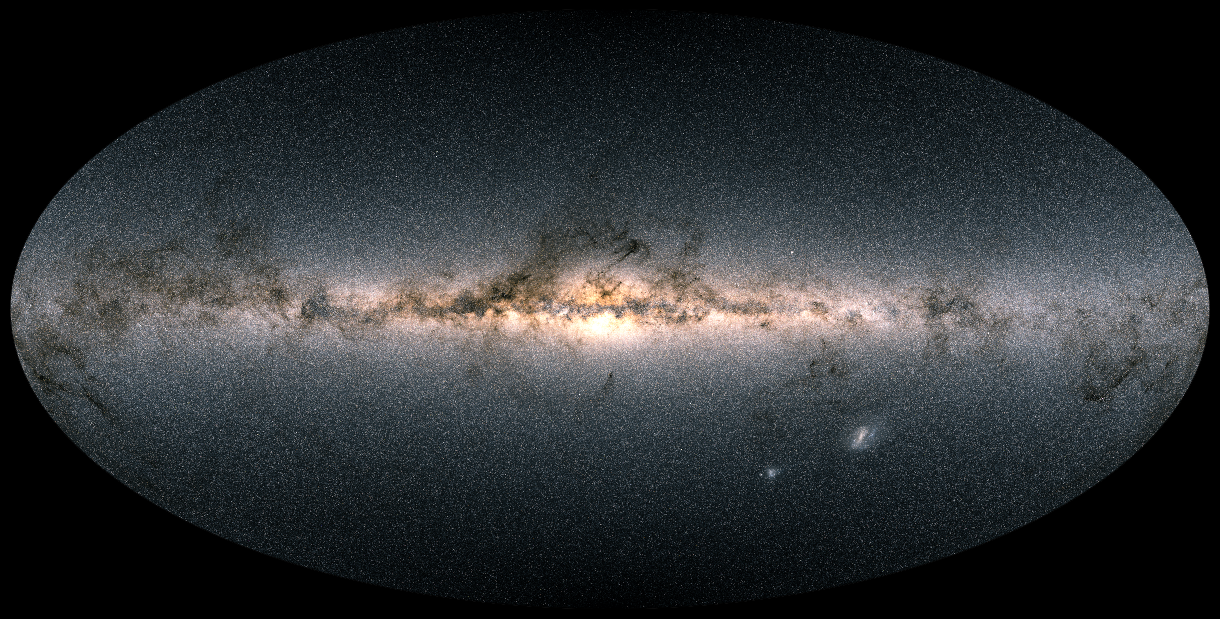

In [5]:

mw_sky = MWSkyMap(
    projection='hammer',    # available projections: 'hammer', 'mollweide', 'aitoff', 'equirectangular'
    background='gaia_edr3',
    figsize=(12, 6),)

# print image information
img_sky = mw_sky._MW_IMAGES["MW_gaia_edr3_fullsky"]
print("Gaia eDR3 All-Sky Map Information")
print(f"Citation/Credit: {img_sky.citation}")
print(f"Source URL:      {img_sky.source_url}")
print(f"License:         {img_sky.license}")
print(f"Size:            {img_sky.pillow_img.size[0]} × {img_sky.pillow_img.size[1]} px")

mw_sky.initialize_mwplot()
mw_sky.ax.set_xticklabels([])
mw_sky.ax.set_yticklabels([])
mw_sky.fig.patch.set_facecolor('black')
mw_sky.fig.tight_layout(pad=0)


Credit: ESA/Gaia/DPAC, Acknowledgement: A. Moitinho | CC BY-SA 3.0 IGO or ESA Standard Licence


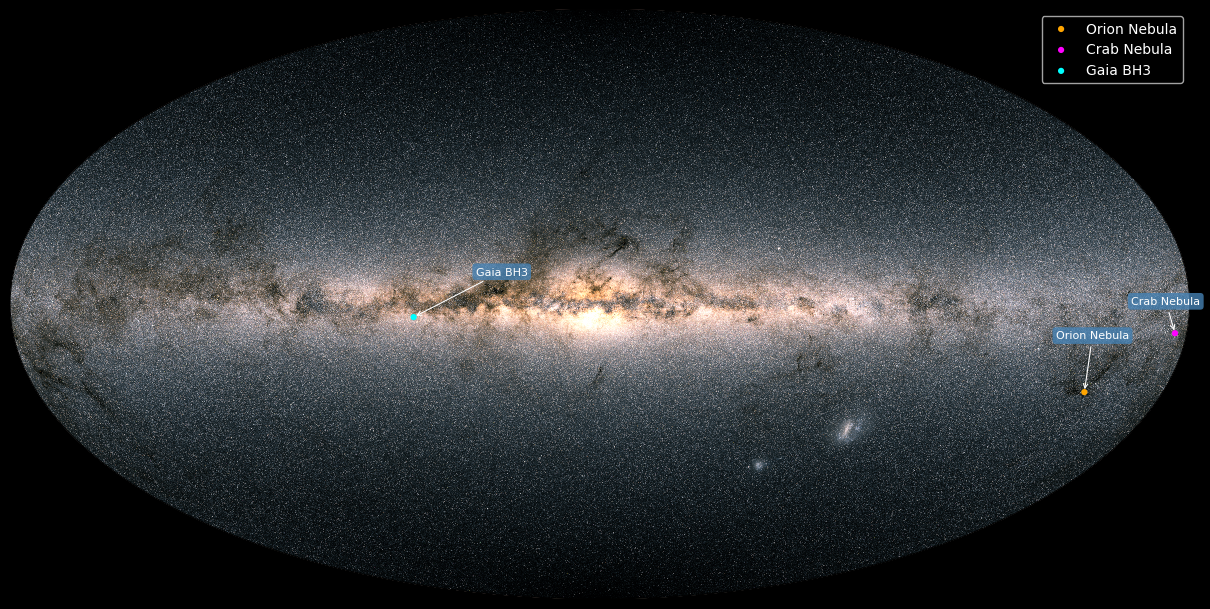

In [9]:
# here no distance to the objects is required
objects_2 = [
    dict(name='Orion Nebula',l=209.011, b=-19.384,color='orange',  marker='o', size=20, sky_offset=(-0.3, 0.2)),     
    dict(name='Crab Nebula', l=184.554, b=-5.783, color='magenta', marker='o', size=20, sky_offset=(-0.3, 0.1)),
    dict(name='Gaia BH3', l=51.673,  b=-3.488,  color='cyan', marker='o', size=20, sky_offset=(0.3, 0.2)),
]

mw_sky = MWSkyMap(projection='hammer',background='gaia_edr3',figsize=(12, 6))
mw_sky.initialize_mwplot()

for obj in objects_2:
    # Option 1: input galactic coordinates (l, b, distance)
    sky = coord.SkyCoord(l=obj['l'] * u.deg, b=obj['b'] * u.deg, frame='galactic')

    # Option 2: input equatorial coordinates (RA, Dec) directly
    # sky = coord.SkyCoord(
    #     ra=alpha1 * u.deg,    # RA in degrees
    #     dec=delta1 * u.deg,   # Dec in degrees
    #     frame='icrs'
    # )

    # annotate (coordinates must be in radians for Hammer projection)
    l_rad = np.deg2rad(-sky.galactic.l.wrap_at(180*u.deg).deg)
    b_rad = np.deg2rad(sky.galactic.b.deg)
    mw_sky.ax.annotate(
        obj['name'],
        xy=(l_rad, b_rad),
        xytext=(l_rad + obj['sky_offset'][0], b_rad + obj['sky_offset'][1]),
        color='white',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='white', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='steelblue', 
                  edgecolor='none', alpha=0.8),
    )

    mw_sky.scatter(sky.icrs.ra, sky.icrs.dec,c=obj['color'],s=obj['size'],marker=obj['marker'],edgecolors='none',label=obj['name'])

mw_sky.ax.legend(loc='upper right', facecolor='black',
                 labelcolor='white', fontsize=10, markerscale=1)
mw_sky.ax.set_xticklabels([])
mw_sky.ax.set_yticklabels([])
mw_sky.fig.patch.set_facecolor('black')
mw_sky.fig.tight_layout(pad=0)

print(f"Credit: {img_sky.citation} | {img_sky.license}")

# save at different resolutions
# max meaningful dpi = image_pixels / figsize_inches = 4000 / 12 = 333
# mw_sky.fig.savefig('mw_allsky_lowres.png',  dpi=72,  bbox_inches='tight', pad_inches=0, facecolor='black')
# mw_sky.fig.savefig('mw_allsky_highres.png', dpi=333, bbox_inches='tight', pad_inches=0, facecolor='black')
